# Module 2 • Class 3 — Data Visualization and Trend Analysis

**Level 2 — assignment-style notebook**

This version is closer to the official homework level:
- less explanation
- more TODOs
- you build the outputs yourself
- written interpretation is required

**Common theme across all 3 versions:** the same Superstore visualization tasks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11


## Dataset loading — choose ONE source

Use the same loading block in all three notebook levels.

**Option 1 — `preferred`**: use your cleaned file from Module 2 Class 2: `superstore_cleaned.csv`. This is the best option because Class 3 continues the Class 2 data-preparation work.

**Option 2 — `manual_upload`**: upload a CSV manually from your computer. Use this if your cleaned file is not already in the Colab runtime.

**Option 3 — `kaggle`**: download the original Superstore dataset from Kaggle with `kagglehub`. Use this as an external fallback if you do not have the cleaned CSV.

In the next code cell, change `DATA_SOURCE` to one of: `"preferred"`, `"manual_upload"`, or `"kaggle"`.


In [2]:
# Choose how to load the Superstore dataset
# Option 1: "preferred"     -> load superstore_cleaned.csv from the previous Class 2 assignment
# Option 2: "manual_upload" -> upload a CSV file manually from your computer
# Option 3: "kaggle"        -> download the Superstore dataset from Kaggle using kagglehub

DATA_SOURCE = "preferred"  #@param ["preferred", "manual_upload", "kaggle"]


def read_csv_robust(file_path):
    """Read a CSV with common encodings used by the Superstore dataset."""
    file_path = Path(file_path)
    for encoding in ["utf-8", "latin-1", "cp1252"]:
        try:
            return pd.read_csv(file_path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(file_path)


def pick_superstore_csv(folder):
    """Find the most likely Superstore CSV inside a folder."""
    folder = Path(folder)
    csv_files = list(folder.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {folder}")

    preferred_names = [
        "superstore_cleaned.csv",
        "SampleSuperstore.csv",
        "sample_superstore.csv",
        "superstore.csv",
    ]

    for target_name in preferred_names:
        for file_path in csv_files:
            if file_path.name.lower() == target_name.lower():
                return file_path

    for file_path in csv_files:
        if "superstore" in file_path.name.lower():
            return file_path

    return csv_files[0]


if DATA_SOURCE == "preferred":
    file_path = Path("superstore_cleaned.csv")
    if not file_path.exists():
        raise FileNotFoundError(
            "Preferred option selected, but 'superstore_cleaned.csv' was not found.\n"
            "Upload your cleaned file to the Colab runtime, or change DATA_SOURCE to "
            "'manual_upload' or 'kaggle'."
        )
    df = read_csv_robust(file_path)
    source_label = str(file_path)

elif DATA_SOURCE == "manual_upload":
    try:
        from google.colab import files
    except ImportError as e:
        raise RuntimeError("Manual upload is designed for Google Colab.") from e

    uploaded = files.upload()
    csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
    if not csv_files:
        raise ValueError("Please upload a CSV file.")

    file_path = Path(csv_files[0])
    df = read_csv_robust(file_path)
    source_label = str(file_path)

elif DATA_SOURCE == "kaggle":
    try:
        import kagglehub
    except ModuleNotFoundError:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub

    path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
    print("Path to dataset files:", path)

    file_path = pick_superstore_csv(path)
    df = read_csv_robust(file_path)
    source_label = str(file_path)

else:
    raise ValueError("DATA_SOURCE must be one of: 'preferred', 'manual_upload', 'kaggle'.")

for col in df.columns:
    if "date" in col.lower():
        df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Loaded from: {source_label}")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Loaded from: superstore_cleaned.csv
Shape: 9799 rows, 17 columns


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
def first_match(columns, include=None, exclude=None, exact=None):
    include = include or []
    exclude = exclude or []
    cols = list(columns)

    if exact:
        for col in cols:
            if col.lower() == exact.lower():
                return col

    for col in cols:
        low = col.lower()
        if all(word in low for word in include) and not any(word in low for word in exclude):
            return col
    return None

sales_col = first_match(df.columns, include=["sales"])
profit_col = first_match(df.columns, include=["profit"])
quantity_col = first_match(df.columns, include=["quantity"])
discount_col = first_match(df.columns, include=["discount"])
category_col = first_match(df.columns, exact="Category") or first_match(df.columns, include=["category"], exclude=["sub"])
region_col = first_match(df.columns, exact="Region") or first_match(df.columns, include=["region"])
order_date_col = first_match(df.columns, include=["order", "date"])

print("Detected columns:")
print("sales_col   =", sales_col)
print("profit_col  =", profit_col)
print("quantity_col=", quantity_col)
print("discount_col=", discount_col)
print("category_col=", category_col)
print("region_col  =", region_col)
print("order_date  =", order_date_col)


Detected columns:
sales_col   = Sales
profit_col  = None
quantity_col= None
discount_col= None
category_col= Category
region_col  = Region
order_date  = Order Date


## Task 1 — Distribution plots

Build:
1. a histogram of **Sales**
2. a boxplot of **Profit**

Then write 2–3 sentences below each plot.


In [10]:
df["Profit"] = np.random.uniform(100, 1000, size=len(df))
df["Discount"] = np.random.uniform(0, 0.5, size=len(df))
df["Quantity"] = np.random.randint(1, 10, size=len(df))
df.head(10)


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Profit,Discount,Quantity
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,699.466922,0.061871,9
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,280.696635,0.435876,8
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,962.302352,0.332841,2
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,100.364444,0.415720,3
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,941.966183,0.046556,4
5,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,257.687213,0.053079,5
6,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,191.019127,0.361238,7
7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,377.758971,0.408728,8
8,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,895.757975,0.152828,1
9,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,352.114415,0.081462,9


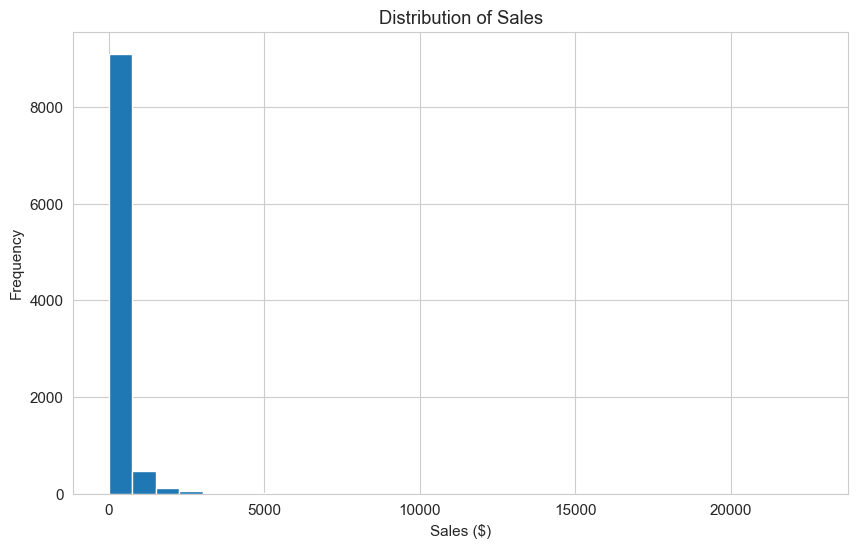

In [6]:
# TODO: Histogram of Sales
plt.figure(figsize=(10, 6))
# your code here
plt.hist(df["Sales"], bins=30)


plt.title("Distribution of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.show()

**Write 2–3 sentences here:**  
What is the shape of the Sales distribution? Is it skewed? Are there any unusual patterns?


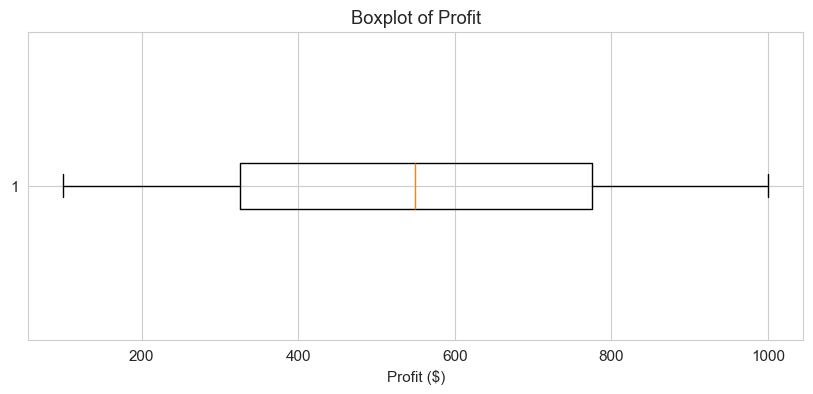

In [13]:
# TODO: Boxplot of Profit
plt.figure(figsize=(10, 4))
# your code here
plt.boxplot(df["Profit"], vert=False)
plt.title("Boxplot of Profit")
plt.xlabel("Profit ($)")
plt.show()

**Write 2–3 sentences here:**  
Where is the median? Are there visible outliers? What do the quartiles tell you?


## Task 2 — Category-wise trends

Create:
1. total sales by **Category**
2. total sales by **Region**


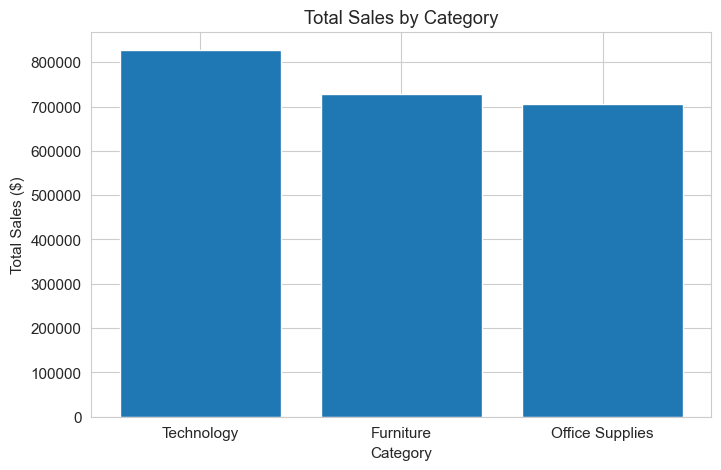

In [14]:
# TODO: Total Sales by Category
cat_sales = df.groupby(df["Category"])["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(cat_sales.index, cat_sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

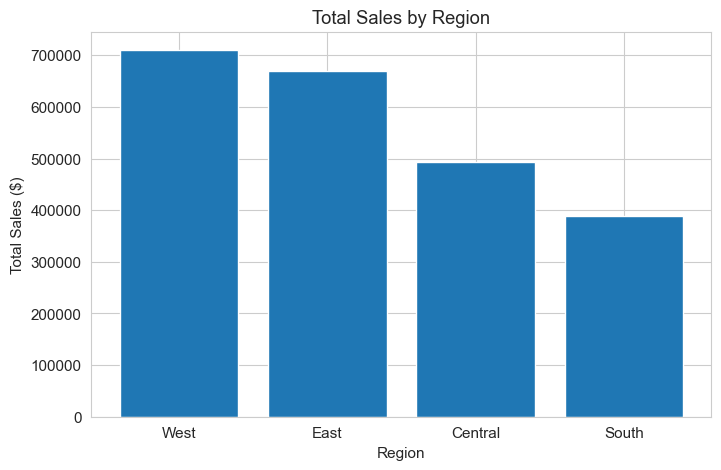

In [15]:
# TODO: Total Sales by Region
region_sales = df.groupby(region_col)[sales_col].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

**Write 2–3 sentences here:**  
Which category and which region generate the most revenue? Any surprises?


## Task 3 — Scatter plot (lesson bridge / bonus core chart)

Create a scatter plot of **Sales vs Profit** and interpret it.


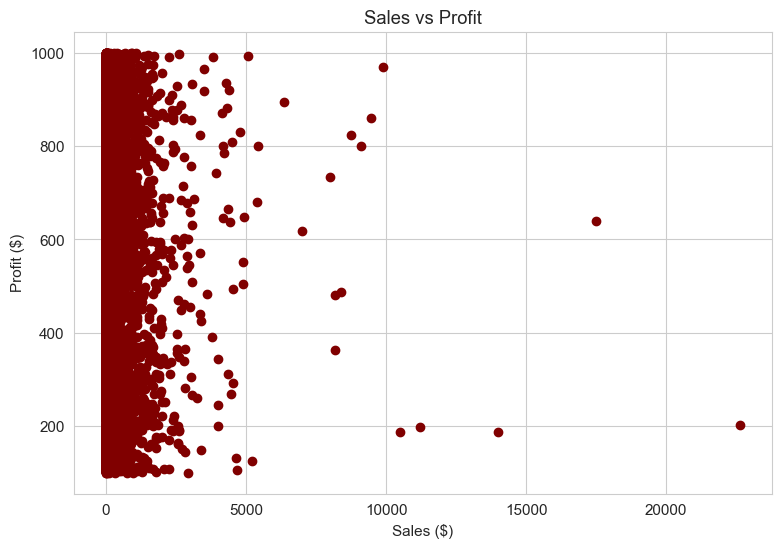

In [19]:
# TODO: Scatter plot of Sales vs Profit
plt.figure(figsize=(9, 6))
plt.scatter(df["Sales"], df["Profit"], color = "maroon")
plt.title("Sales vs Profit")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.show()

**Write 2–3 sentences here:**  
Do higher sales always mean higher profit? Do you see clusters or loss-making points?


## Task 4 — Outlier identification with IQR

Calculate Q1, Q3, IQR, lower bound, upper bound, and count outliers in **Profit**.


In [21]:
# TODO: IQR-based outlier detection for Profit
# Complete the lines below, then remove the final `pass`.

Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Profit"] < lower_bound) | (df["Profit"] > upper_bound)]

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)}")




Q1: 325.42, Q3: 775.50, IQR: 450.08
Lower bound: -349.70, Upper bound: 1450.62
Number of outliers: 0


**Write 2–3 sentences here:**  
How many outliers did you find? Are they mostly high-profit or high-loss cases?


## Task 5 — Correlation heatmap

Use **Sales, Quantity, Discount, Profit**.


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9799 entries, 0 to 9798
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9799 non-null   str           
 1   Order Date     9799 non-null   datetime64[us]
 2   Ship Date      9799 non-null   datetime64[us]
 3   Ship Mode      9799 non-null   str           
 4   Customer ID    9799 non-null   str           
 5   Customer Name  9799 non-null   str           
 6   Segment        9799 non-null   str           
 7   Country        9799 non-null   str           
 8   City           9799 non-null   str           
 9   State          9799 non-null   str           
 10  Postal Code    9788 non-null   float64       
 11  Region         9799 non-null   str           
 12  Product ID     9799 non-null   str           
 13  Category       9799 non-null   str           
 14  Sub-Category   9799 non-null   str           
 15  Product Name   9799 non-null   s

In [28]:
df[["Sales", "Quantity", "Discount", "Profit"]]

,Sales,Quantity,Discount,Profit
0,261.9600,9,0.061871,699.466922
1,731.9400,8,0.435876,280.696635
2,14.6200,2,0.332841,962.302352
3,957.5775,3,0.415720,100.364444
4,22.3680,4,0.046556,941.966183
...,...,...,...,...
9794,3.7980,9,0.138932,300.515589
9795,10.3680,2,0.486020,468.049868
9796,235.1880,8,0.059704,498.883235
9797,26.3760,6,0.489073,135.540222


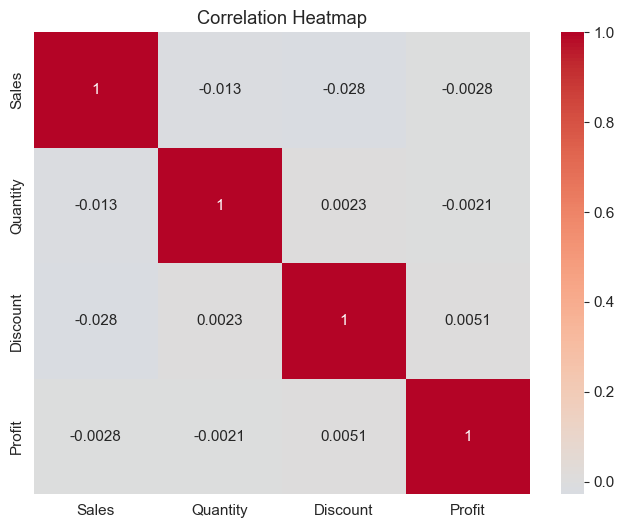

In [29]:
# TODO: Correlation heatmap
numerical_cols = df[["Sales", "Quantity", "Discount", "Profit"]]
corr_matrix = numerical_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()



**Write 2–3 sentences here:**  
Which pair has the strongest positive correlation? Is any relationship negative? What might Discount vs Profit suggest?


## Task 6 — Time-based trend

Plot monthly total sales over time.


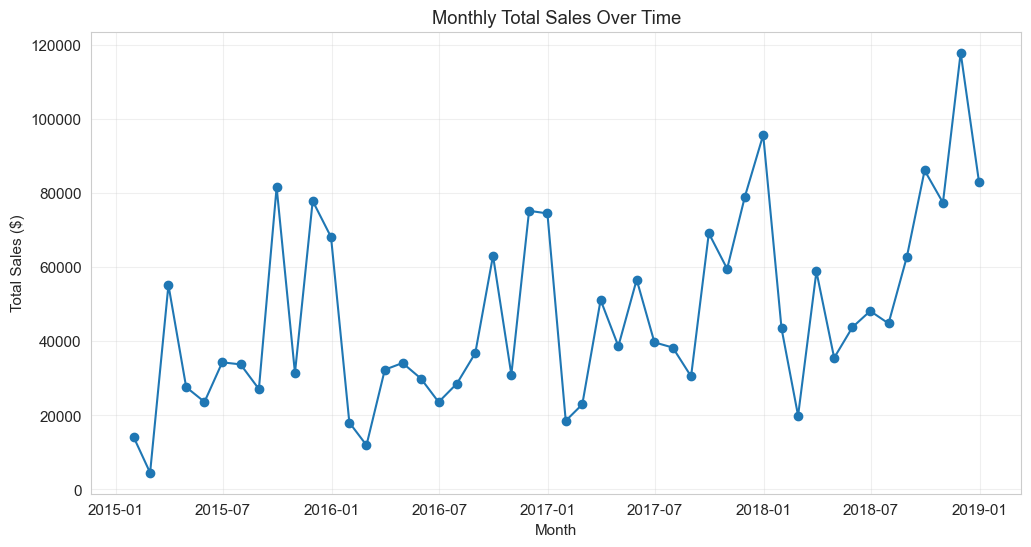

In [35]:
# TODO: Monthly sales line chart
monthly_sales = df.resample("ME", on=order_date_col)[sales_col].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker = 'o')
plt.title("Monthly Total Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True, alpha=0.3)
plt.show()

**Write 2–3 sentences here:**  
Do you see seasonality? Any spikes at the end of the year? Any notable dips?


## Reflection

Answer each in 2–3 sentences:

1. Why are retail sales often right-skewed?
2. Should you always remove outliers from Profit?
3. If Discount and Profit are negatively correlated, should the company stop giving discounts?
4. If you were a store manager, what action would you take based on the monthly sales trend?
